In [177]:
!pip install -q catboost

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#EDA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score
)

In [179]:
print("[   2-LOAD DATA    ]\n")
#load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

#data shape
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", sample_submission.shape)

[   2-LOAD DATA    ]

Train shape: (39073, 15)
Test shape: (9769, 15)
Submission shape: (9769, 2)


In [180]:
print("[     3-DATA UNDERSTANDING     ]\n")
print("5 DATA TERATAS")
display(train.head())

print("\n5 DATA TERBAWAH")
display(train.tail())

[     3-DATA UNDERSTANDING     ]

5 DATA TERATAS


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,37,Private,193106,Bachelors,13,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States,<=50K.
1,56,Self-emp-inc,216636,12th,8,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1651,40,United-States,<=50K
2,53,Private,126977,HS-grad,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,35,United-States,<=50K
3,72,Private,205343,11th,7,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
4,46,State-gov,106705,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,38,United-States,<=50K



5 DATA TERBAWAH


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
39068,45,Private,37718,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,>50K.
39069,58,State-gov,223400,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,White,Female,0,0,20,United-States,>50K
39070,61,Federal-gov,229062,Some-college,10,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,1887,40,United-States,>50K
39071,38,Private,81965,Assoc-voc,11,Never-married,Tech-support,Not-in-family,White,Female,0,0,40,United-States,<=50K
39072,43,State-gov,114191,Some-college,10,Married-civ-spouse,Protective-serv,Husband,Asian-Pac-Islander,Male,0,0,40,United-States,<=50K.


In [181]:
#data info
print("\n---DATA INFO---")

print("\nTEST INFO")
train.info()

print("\nTEST INFO")
test.info()


---DATA INFO---

TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39073 entries, 0 to 39072
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             39073 non-null  int64 
 1   workclass       38304 non-null  object
 2   fnlwgt          39073 non-null  int64 
 3   education       39073 non-null  object
 4   education-num   39073 non-null  int64 
 5   marital-status  39073 non-null  object
 6   occupation      38302 non-null  object
 7   relationship    39073 non-null  object
 8   race            39073 non-null  object
 9   sex             39073 non-null  object
 10  capital-gain    39073 non-null  int64 
 11  capital-loss    39073 non-null  int64 
 12  hours-per-week  39073 non-null  int64 
 13  native-country  38851 non-null  object
 14  income          39073 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.5+ MB

TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9769

In [182]:
#tipe data
print("\n---DATA TYPES---")
display(train.dtypes.to_frame(name="data types"))


---DATA TYPES---


,data types
age,int64
workclass,object
fnlwgt,int64
education,object
education-num,int64
marital-status,object
occupation,object
relationship,object
race,object
sex,object


Jawaban Bonus 2.a

In [183]:
categorical_cols = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'income'
]

In [184]:
print('---UNIQUE VALUES---')

unique_df = pd.DataFrame({
    "column": train.columns,
    "unique_count": [
        train[col].nunique(dropna=False)
        for col in train.columns
    ]
})

display(unique_df)

print('\n---CATEGORICAL UNIQUE VALUES---')
unique_df_categorical = pd.DataFrame({
    "column": categorical_cols,
    "unique_count": [
        train[col].nunique(dropna=False)
        for col in categorical_cols
    ]
})

display(unique_df_categorical)


---UNIQUE VALUES---


,column,unique_count
0,age,73
1,workclass,10
2,fnlwgt,24615
3,education,16
4,education-num,16
5,marital-status,7
6,occupation,16
7,relationship,6
8,race,5
9,sex,2



---CATEGORICAL UNIQUE VALUES---


,column,unique_count
0,workclass,10
1,education,16
2,marital-status,7
3,occupation,16
4,relationship,6
5,race,5
6,sex,2
7,native-country,43
8,income,4


In [185]:
print('---NUMERICAL STATISTIC---')
display(train.describe())

---NUMERICAL STATISTIC---


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,39073.000000,3.907300e+04,39073.000000,39073.000000,39073.000000,39073.000000
mean,38.643488,1.899922e+05,10.069844,1038.040540,86.807949,40.476877
std,13.685634,1.054768e+05,2.574387,7204.953114,401.276773,12.401251
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.177670e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.786150e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.383290e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [186]:

print("\nJumlah data kosong di tiap kolom:")
display(train.isnull().sum().sort_values(ascending=False))


Jumlah data kosong di tiap kolom:


,0
occupation,771
workclass,769
native-country,222
fnlwgt,0
education,0
education-num,0
age,0
marital-status,0
relationship,0
sex,0


In [187]:
for col in train.select_dtypes(include="object").columns:
    count = (train[col] == "?").sum()
    if count > 0:
        print('missing in', col, '=', count)

missing in workclass = 1464
missing in occupation = 1470
missing in native-country = 466


In [188]:
print("\nJumlah baris yang duplikat persis:")
print(train.duplicated().sum())


Jumlah baris yang duplikat persis:
21


In [189]:
print('[     DATA CLEANTING    ]')
train_fix = train.copy()
test_fix = test.copy()
print("Train sebelum cleaning :", train_fix.shape)
print("Test sebelum cleaning  :", test_fix.shape)

[     DATA CLEANTING    ]
Train sebelum cleaning : (39073, 15)
Test sebelum cleaning  : (9769, 15)


In [190]:
train_fix = train_fix.replace("?", np.nan)
test_fix = test_fix.replace("?", np.nan)
print('Data berhasil diubah')

Data berhasil diubah


Jawaban Bonus 2.b

In [191]:
print("Missing values setelah '?' diubah menjadi NaN :")
display(train_fix.isnull().sum().sort_values(ascending=False))

Missing values setelah '?' diubah menjadi NaN :


,0
occupation,2241
workclass,2233
native-country,688
fnlwgt,0
education,0
education-num,0
age,0
marital-status,0
relationship,0
sex,0


In [192]:
#ada penulisan income yang ga sesuai
train_fix["income"] = (
    train_fix["income"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

print("Jenis income setelah cleaning:")
print(train_fix["income"].unique())

Jenis income setelah cleaning:
['<=50K' '>50K']


In [193]:
duplicate_count = train_fix.duplicated().sum()

print("Duplicate sebelum dihapus:", duplicate_count)

train_fix = train_fix.drop_duplicates().reset_index(drop=True)

print("Duplicate setelah dihapus:", train_fix.duplicated().sum())
print("Train shape setelah duplicate removal:", train_fix.shape)

Duplicate sebelum dihapus: 35
Duplicate setelah dihapus: 0
Train shape setelah duplicate removal: (39038, 15)


In [194]:
print('[     DATA QUALITY     ]')

print("\ntrain shape :")
print(train_fix.shape)

print("\nJumlah duplicate:")
print(train_fix.duplicated().sum())

print("\nmissing :")
display(train_fix.isnull().sum().sort_values(ascending=False))

print("\nunique income")
display(train_fix['income'].value_counts(dropna=False))



[     DATA QUALITY     ]

train shape :
(39038, 15)

Jumlah duplicate:
0

missing :


,0
occupation,2237
workclass,2229
native-country,688
fnlwgt,0
education,0
education-num,0
age,0
marital-status,0
relationship,0
sex,0



unique income


,count
income,
<=50K,29694
>50K,9344


In [195]:
print('[    EDA    ]')

[    EDA    ]


a. INCOME DISTRIBUTION


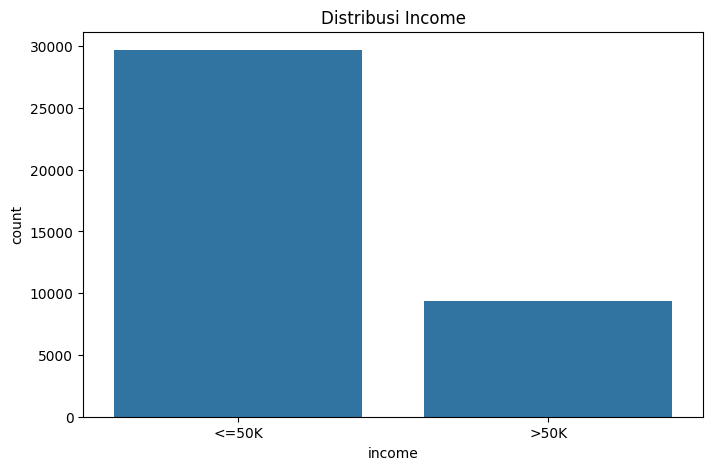

b. AGE VS INCOME


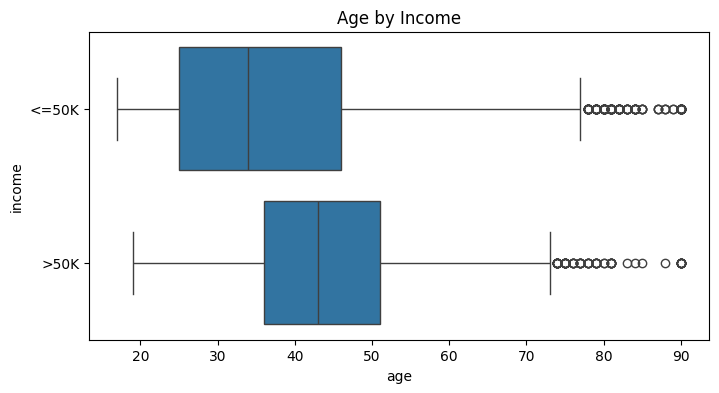

c. Work Hours VS Income


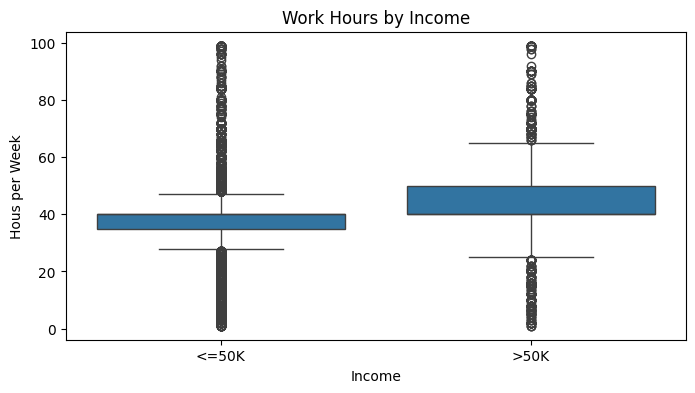

d. Capital Gain VS Income


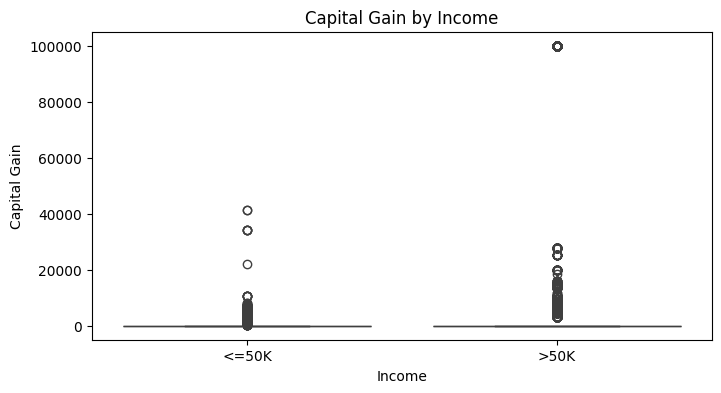

e. Education VS Income


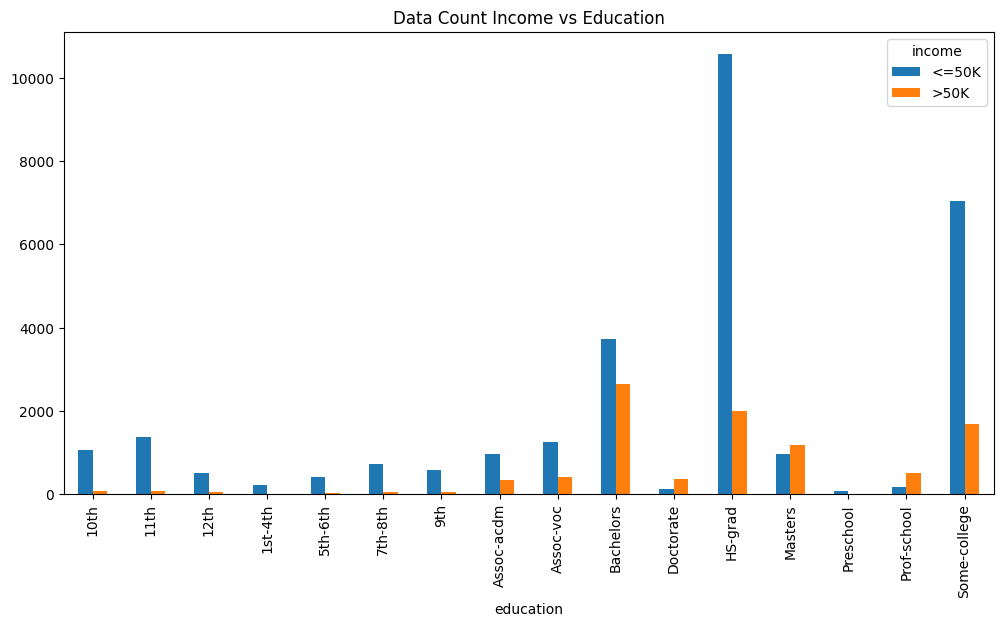

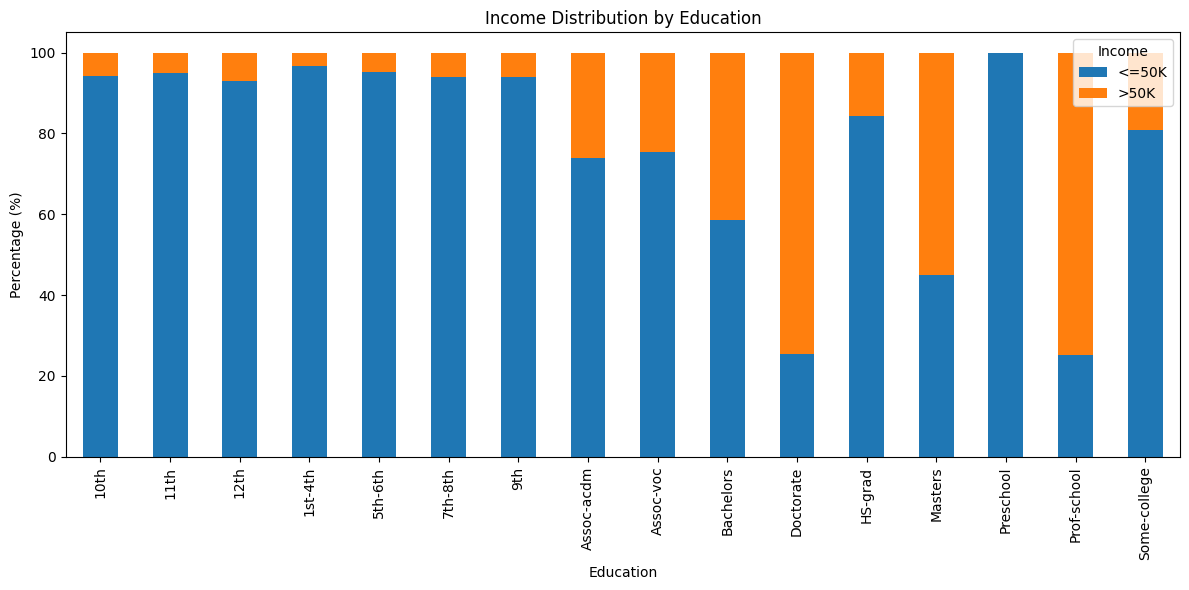

f. Occupation VS Income


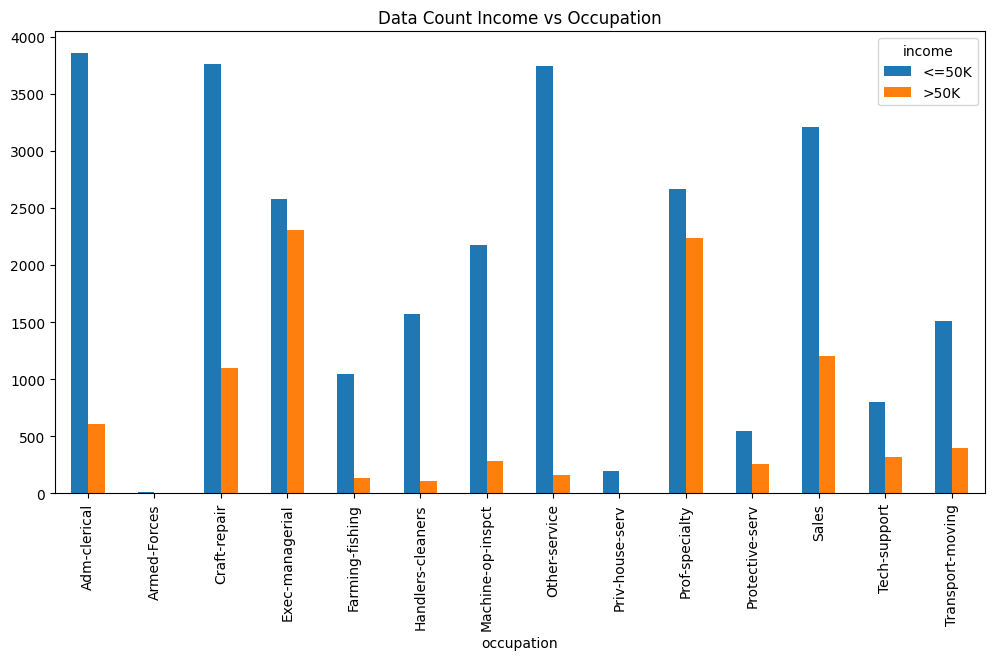

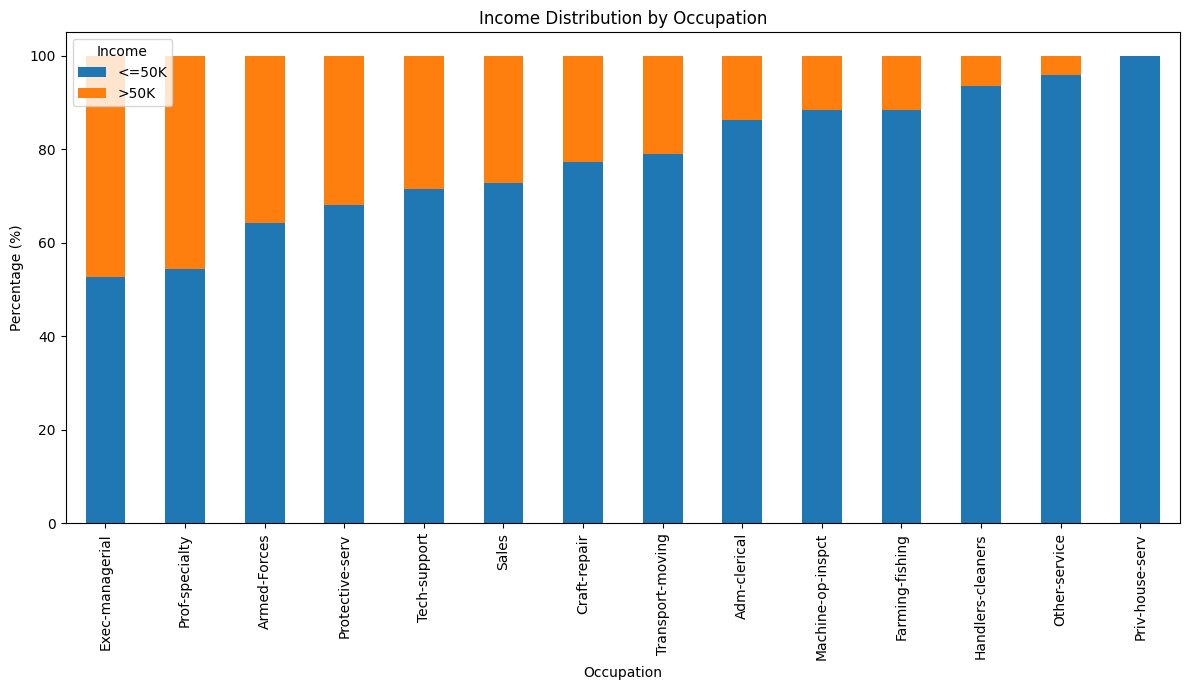

g.occupation VS work hours

Mean of Work Hours by occupation


,hours-per-week
occupation,
Adm-clerical,37.905466
Armed-Forces,41.142857
Craft-repair,42.266187
Exec-managerial,44.931479
Farming-fishing,46.511036
Handlers-cleaners,37.959451
Machine-op-inspct,40.830826
Other-service,34.794714
Priv-house-serv,32.873737


h.education VS capital gain

Mean of capital gain by education


,capital-gain
education,
10th,325.076715
11th,207.998622
12th,155.832392
1st-4th,126.156398
5th-6th,427.823944
7th-8th,228.656085
9th,351.988543
Assoc-acdm,645.834229
Assoc-voc,613.629451


In [212]:
print('a. INCOME DISTRIBUTION')
plt.figure(figsize=(8, 5))
sns.countplot(data=train_fix, x='income')
plt.title('Distribusi Income')
plt.show()

print('b. AGE VS INCOME')
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_fix, x='age', y = 'income')
plt.title('Age by Income')
plt.show()

print('c. Work Hours VS Income')
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_fix, x='income', y = 'hours-per-week')
plt.title('Work Hours by Income')
plt.xlabel("Income")
plt.ylabel("Hous per Week")
plt.show()

print('d. Capital Gain VS Income')
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_fix, x='income', y = 'capital-gain')
plt.title('Capital Gain by Income')
plt.xlabel("Income")
plt.ylabel("Capital Gain")
plt.show()

#bonus
print('e. Education VS Income')
#jumlah individunya
count_education_income = pd.crosstab(
    train_fix['education'],
    train_fix['income']
)

count_education_income.plot(
    kind='bar',
    figsize=(12, 6)
)
plt.title("Data Count Income vs Education")

#proporsinya
education_income = pd.crosstab(
    train_fix["education"],
    train_fix["income"],
    normalize="index"
) * 100

education_income.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Income Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Percentage (%)")
plt.legend(title="Income")

plt.tight_layout()
plt.show()


print('f. Occupation VS Income')

#jumlah individunya
count_education_income = pd.crosstab(
    train_fix['occupation'],
    train_fix['income']
)

count_education_income.plot(
    kind='bar',
    figsize=(12, 6)
)
plt.title("Data Count Income vs Occupation")

#proporsinya
occupation_income = pd.crosstab(
    train_fix["occupation"],
    train_fix["income"],
    normalize="index"
) * 100

occupation_income = occupation_income.sort_values(
    ">50K",
    ascending=False
)

occupation_income.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Income Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Income")

plt.tight_layout()
plt.show()

print("g.occupation VS work hours")
print("\nMean of Work Hours by occupation")
avg_hours = train_fix.groupby('occupation')['hours-per-week'].mean()
display(avg_hours)

print("h.education VS capital gain")
print("\nMean of capital gain by education")
avg_capgain = train_fix.groupby('education')['capital-gain'].mean()
display(avg_capgain)





In [197]:
print('[   PREPROCESSING   ]')

print('---DATA SPLITING---')
#target dan fitur
X = train_fix.drop(columns=["income"])
y = train_fix["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

split_distribution = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True) * 100,
    "Validation (%)": y_test.value_counts(normalize=True) * 100
})

display(split_distribution.round(2))


[   PREPROCESSING   ]
---DATA SPLITING---


,Train (%),Validation (%)
income,,
<=50K,76.06,76.06
>50K,23.94,23.94


In [198]:
print("---FEATURES TYPES---")

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nJumlah categorical:", len(categorical_features))
print("Jumlah numerical:", len(numerical_features))

---FEATURES TYPES---
Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Numerical features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Jumlah categorical: 8
Jumlah numerical: 6


In [199]:
print('--- preprocessing pipeline---')
# Numerical pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

# Gabungkan semuanya
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


--- preprocessing pipeline---


In [200]:
print('[     FEATURE ENGINEERING     ]')
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe["capital-gain-log"] = np.log1p(
    X_train_fe["capital-gain"]
)

X_test_fe["capital-gain-log"] = np.log1p(
    X_test_fe["capital-gain"]
)

X_train_fe["capital-loss-log"] = np.log1p(
    X_train_fe["capital-loss"]
)

X_test_fe["capital-loss-log"] = np.log1p(
    X_test_fe["capital-loss"]
)

print("Original features :", X_train.shape[1])
print("After engineering :", X_train_fe.shape[1])

print("\nNew features:")
print([
    "capital-gain-log",
    "capital-loss-log"
])

[     FEATURE ENGINEERING     ]
Original features : 14
After engineering : 16

New features:
['capital-gain-log', 'capital-loss-log']


In [201]:
print("---NEW FEATURES TYPES---")
categorical_features_fe = X_train_fe.select_dtypes(include=["object"]).columns.tolist()

numerical_features_fe = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:")
print(categorical_features_fe)

print("\nNumerical features:")
print(numerical_features_fe)

print("\nJumlah categorical:", len(categorical_features_fe))
print("Jumlah numerical:", len(numerical_features_fe))

---NEW FEATURES TYPES---
Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Numerical features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital-gain-log', 'capital-loss-log']

Jumlah categorical: 8
Jumlah numerical: 8


In [202]:
print("---PREPROCESSING FEATURE ENGINEERING---")

numeric_transformer_fe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_fe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_fe,
            numerical_features_fe
        ),
        (
            "cat",
            categorical_transformer_fe,
            categorical_features_fe
        )
    ]
)


---PREPROCESSING FEATURE ENGINEERING---


In [203]:
print("[     MODEL 1 : Logistic Regression    ]")
#logistic regression
log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

log_reg.fit(X_train_fe, y_train)

print("Logistic Regression training selesai.")


[     MODEL 1 : Logistic Regression    ]
Logistic Regression training selesai.


In [204]:
y_pred_lr = log_reg.predict(
    X_test_fe
)

print("Prediction selesai.")

Prediction selesai.


In [205]:
f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="macro"
)

print(
    f"Logistic Regression F1-Macro: {f1_lr:.4f}"
)

Logistic Regression F1-Macro: 0.7850


In [206]:
print("[     MODEL 2 : Random Forest    ]")
#random forest
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

random_forest_model.fit(
    X_train_fe,
    y_train
)

print("Random Forest training selesai.")

[     MODEL 2 : Random Forest    ]


KeyboardInterrupt: 

In [ ]:

y_pred_rf = random_forest_model.predict(
    X_test_fe
)


In [ ]:
f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="macro"
)

print(
    f"Random Forest F1-Macro: {f1_rf:.4f}"
)

In [ ]:
print("---KLASIFIKASI RANDOM FOREST---")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

In [ ]:
print("[     MODEL 3 : CATBOOST    ]")

#penanganan isi data
X_train_cb = X_train_fe.copy()
X_test_cb = X_test_fe.copy()

for col in categorical_features_fe:
    X_train_cb[col] = X_train_cb[col].fillna("Missing").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("Missing").astype(str)

cat_features_indices = [
    X_train_cb.columns.get_loc(col)
    for col in categorical_features_fe
]

print("Categorical features:")
print(categorical_features_fe)

print("\nJumlah categorical features:", len(cat_features_indices))

In [ ]:
#catboost
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=7,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=RANDOM_STATE,
    verbose=100,
    thread_count=-1
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features_indices
)

print("CatBoost training selesai.")

In [ ]:
y_pred_cb = catboost_model.predict(
    X_test_cb
).flatten()

print("CatBoost prediction selesai.")

In [ ]:
f1_cb = f1_score(
    y_test,
    y_pred_cb,
    average="macro"
)

print(
    f"CatBoost F1-Macro: {f1_cb:.4f}"
)

In [ ]:
print("---KLASIFIKASI CATBOOST---")

print(
    classification_report(
        y_test,
        y_pred_cb
    )
)

In [ ]:
print("[     MODEL FE COMPARISON    ]")
#perbandingan model
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost"
    ],
    "F1-Macro": [
        f1_lr,
        f1_rf,
        f1_cb
    ]
})

results = results.sort_values(
    "F1-Macro",
    ascending=False
).reset_index(drop=True)

display(results)

In [ ]:
print("[     MODEL FE VISUALISATION     ]")
#model visualisation
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="F1-Macro"
)

plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Macro")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f"
    )

plt.tight_layout()
plt.show()

In [ ]:
print("[     WITHOUT FEATURE ENGINEERING    ]")

print("[     CATBOOST BASELINE    ]")
X_train_cb_base = X_train.copy()
X_test_cb_base = X_test.copy()

for col in categorical_features:
    X_train_cb_base[col] = (
        X_train_cb_base[col]
        .fillna("Missing")
        .astype(str)
    )

    X_test_cb_base[col] = (
        X_test_cb_base[col]
        .fillna("Missing")
        .astype(str)
    )

cat_features_indices_base = [
    X_train_cb_base.columns.get_loc(col)
    for col in categorical_features
]

print("Jumlah fitur original:", X_train_cb_base.shape[1])
print("Jumlah categorical:", len(cat_features_indices_base))

In [ ]:
#catboost model baseline
catboost_base = CatBoostClassifier(
    iterations=500,
    depth=7,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=RANDOM_STATE,
    verbose=100,
    thread_count=-1
)

catboost_base.fit(
    X_train_cb_base,
    y_train,
    cat_features=cat_features_indices_base
)

print("CatBoost baseline training selesai.")

In [ ]:
y_pred_cb_base = catboost_base.predict(
    X_test_cb_base
).flatten()

print("Prediction selesai.")

In [ ]:
f1_cb_base = f1_score(
    y_test,
    y_pred_cb_base,
    average="macro"
)

print(
    f"CatBoost WITHOUT Feature Engineering F1-Macro: "
    f"{f1_cb_base:.4f}"
)

In [ ]:
print("[     MODEL COMPARISON WITH & WITHOUT FE     ]")
#fperbandingan model dengan dan tanpa FE

fe_comparison = pd.DataFrame({
    "Experiment": [
        "CatBoost - Original Features",
        "CatBoost - Feature Engineering"
    ],
    "F1-Macro": [
        f1_cb_base,
        f1_cb
    ]
})

display(
    fe_comparison.sort_values(
        "F1-Macro",
        ascending=False
    ).reset_index(drop=True)
)

In [ ]:
print("[     LOGISTIC REGRESSION BASELINE    ]")
#logistic regression basline

logistic_base = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_base.fit(
    X_train,
    y_train
)

y_pred_lr_base = logistic_base.predict(
    X_test
)

f1_lr_base = f1_score(
    y_test,
    y_pred_lr_base,
    average="macro"
)

print(
    f"Logistic Regression - Original F1-Macro: "
    f"{f1_lr_base:.4f}"
)

In [ ]:
print("[     RANDOME FOREST BASELINE    ]")
#random foest baseline

random_forest_base = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

random_forest_base.fit(
    X_train,
    y_train
)

y_pred_rf_base = random_forest_base.predict(
    X_test
)

f1_rf_base = f1_score(
    y_test,
    y_pred_rf_base,
    average="macro"
)

print(
    f"Random Forest - Original F1-Macro: "
    f"{f1_rf_base:.4f}"
)

In [ ]:
print("[     MODEL BASELINE COMPARISON    ]")
#model baseline comparison

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost"
    ],
    "F1-Macro": [
        f1_lr_base,
        f1_rf_base,
        f1_cb_base
    ]
})

final_results = final_results.sort_values(
    "F1-Macro",
    ascending=False
).reset_index(drop=True)

display(final_results)

In [ ]:
print("[     MODEL BASELINE VISUALISATION    ]")
#visual model baseline comaprison
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=final_results,
    x="Model",
    y="F1-Macro"
)

plt.title("Final Model Comparison - Original Features")
plt.xlabel("Model")
plt.ylabel("F1-Macro")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f"
    )

plt.tight_layout()
plt.show()

In [ ]:
print("[     FINALIZATION    ]")
#prepare data final
X_full = train_fix.drop(columns=["income"]).copy()
y_full = train_fix["income"].copy()

X_test_final = test_fix[X_full.columns].copy()

print("X_full shape :", X_full.shape)
print("y_full shape :", y_full.shape)
print("X_test shape :", X_test_final.shape)

print("\nFeature consistency:")
print("Train features :", list(X_full.columns))
print("Test features  :", list(X_test_final.columns))

In [ ]:
print("---FINAL FEATURES---")
#final features

categorical_features_final = X_full.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features_final = X_full.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features_final)

print("\nNumerical features:")
print(numerical_features_final)

print("\nJumlah categorical:", len(categorical_features_final))
print("Jumlah numerical:", len(numerical_features_final))

In [ ]:
print("---HANDLE MISSING VALUE---")
#handle missing value
for col in categorical_features_final:
    X_full[col] = (
        X_full[col]
        .fillna("Missing")
        .astype(str)
    )

    X_test_final[col] = (
        X_test_final[col]
        .fillna("Missing")
        .astype(str)
    )

# Index kolom categorical untuk CatBoost
cat_features_final_indices = [
    X_full.columns.get_loc(col)
    for col in categorical_features_final
]

print("Categorical missing values handled.")

print("\nCategorical indices:")
print(cat_features_final_indices)

In [ ]:
#final catboost
final_catboost = CatBoostClassifier(
    iterations=500,
    depth=7,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=RANDOM_STATE,
    verbose=100,
    thread_count=-1
)

# training all data
final_catboost.fit(
    X_full,
    y_full,
    cat_features=cat_features_final_indices
)


In [ ]:
#final prediction
test_predictions = final_catboost.predict(
    X_test_final
).flatten()

print("Prediction selesai.")

print("\nJumlah prediction:", len(test_predictions))

print("\nPrediction distribution:")
print(
    pd.Series(test_predictions)
    .value_counts()
)

In [ ]:
print("Test rows       :", len(X_test_final))
print("Predictions     :", len(test_predictions))

print("\nUnique predictions:")
print(np.unique(test_predictions))

print("\nPrediction counts:")
display(
    pd.Series(
        test_predictions,
        name="income"
    ).value_counts()
)

In [ ]:
("[    SUBMISSION    ]")

#sample submission
sample_submission = pd.read_csv(
    "sample_submission.csv"
)

print("\nShape:")
print(sample_submission.shape)

print("\nColumns:")
print(sample_submission.columns.tolist())

display(sample_submission.head())

In [ ]:
submission = sample_submission.copy()

submission["income"] = test_predictions

print("Submission berhasil dibuat.")

print("\nShape:")
print(submission.shape)

print("\nColumns:")
print(submission.columns.tolist())

display(submission.head(10))

In [ ]:
#submission
submission.to_csv(
    "submission.csv",
    index=False
)